For the visualisation functions quick note:


**fm_display()** - displays the C matrix and the pointwise visualisation between mesh 1 and mesh 2.


**double_fm_display()** - displays the C matrix from both ZoomOut Refinerment methods and the pointwise visualisation of both maps on mesh 2 ONLY.

In [54]:
import matplotlib.pyplot as plt
import open3d as o3d
import numpy as np
import json
import os

import pyFM.spectral as spectral
from pyFM.mesh import TriMesh

from tqdm.auto import tqdm
import meshplot as mp

INTERVAL = 4

# Setting up Plotting Functions
def double_pcd_plot_o3d(myCloud1, myCloud2, cmap1=None, cmap2=None):
    vertlist_1 = np.asarray(myCloud1.points)
    vertlist_2 = np.asarray(myCloud2.points)

    d = mp.subplot(vertlist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, c=cmap2, s=[2, 2, 1], data=d)

def double_plot_o3d(myMesh1,myMesh2,cmap1=None,cmap2=None):
    vertlist_1 = np.asarray(myMesh1.vertices)
    facelist_1 = np.asarray(myMesh1.triangles)

    vertlist_2 = np.asarray(myMesh2.vertices)
    facelist_2 = np.asarray(myMesh2.triangles)
    
    d = mp.subplot(vertlist_1, facelist_1, c=cmap1, s=[2, 2, 0])
    mp.subplot(vertlist_2, facelist_2, c=cmap2, s=[2, 2, 1], data=d)
    
def double_plot(myMesh1,myMesh2,cmap1=None,cmap2=None):
    d = mp.subplot(myMesh1.vertlist, myMesh1.facelist, c=cmap1, s=[2, 2, 0])
    mp.subplot(myMesh2.vertlist, myMesh2.facelist, c=cmap2, s=[2, 2, 1], data=d)

def visu(vertices):
    min_coord,max_coord = np.min(vertices,axis=0,keepdims=True),np.max(vertices,axis=0,keepdims=True)
    cmap = (vertices-min_coord)/(max_coord-min_coord)
    return cmap

# For Display
def fm_display(ind_1, ind_2, maps, mesh_display=False, meshes=None):
    
    fm_12 = maps[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12.shape}")
    plt.matshow(fm_12)
    plt.title(f"C mat after ZoomOut - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        p2p_21 = spectral.convert.mesh_FM_to_p2p(fm_12, mesh1, mesh2) # need to look at this function properly

        cmap_1 = visu(mesh1.vertlist)
        cmap_2 = cmap_1[p2p_21]
        double_plot(mesh1, mesh2, cmap_1, cmap_2)

def double_fm_display(ind_1, ind_2, maps1, maps2, mesh_display=False, meshes=None):
    
    fm_12_1 = maps1[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_1.shape}")
    plt.matshow(fm_12_1)
    plt.title(f"Original Point to Point Map - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()


    fm_12_2 = maps2[(ind_1, ind_2)]
    
    print(f"new map shape: {fm_12_2.shape}")
    plt.matshow(fm_12_2)
    plt.title(f"Original Compounded Map - mesh {ind_1+1} -> mesh {ind_2+1}")
    plt.show()

    if mesh_display:
        mesh1, mesh2 = meshes[ind_1], meshes[ind_2]
        cmap_1 = visu(mesh1.vertlist)

        p2p_21_1 = spectral.convert.mesh_FM_to_p2p(fm_12_1, mesh1, mesh2)
        p2p_21_2 = spectral.convert.mesh_FM_to_p2p(fm_12_2, mesh1, mesh2)

        cmap_2_1 = cmap_1[p2p_21_1]
        cmap_2_2 = cmap_1[p2p_21_2]

        double_plot(mesh2, mesh2, cmap_2_1, cmap_2_2)


# Step 1. Data Pre-Processing

In [2]:
def processed_TriMesh(mesh):

    # clean mesh
    mesh.remove_duplicated_vertices()
    mesh.remove_degenerate_triangles()
    mesh.remove_unreferenced_vertices()

    verts, faces = np.asarray(mesh.vertices), np.asarray(mesh.triangles)
    
    # Create a TriMesh
    mesh_pyfm = TriMesh(verts, faces, area_normalize=True, center=True)
    mesh_pyfm.process(k=150, intrinsic=True) # why is this section so hard to process!!!!

    return mesh_pyfm

def load_gt_from_json(path, frame):
    """Loads ray-traced ground-truth hit points from 4 cameras for a given frame."""
    all_points = []
    for i in range(4):
        cam_path = os.path.join(path, f"Camera_{i+1}", f"frame_{frame}.json")
        if not os.path.exists(cam_path):
            print(f"Warning: Missing {cam_path}")
            continue

        with open(cam_path, 'r') as f:
            camera_hit_list = json.load(f)

        hit_points = np.array([entry['hit'] for entry in camera_hit_list if entry['hit'] is not None], dtype=np.float32)
        all_points.append(hit_points)

    if len(all_points) == 0:
        raise RuntimeError(f"No valid GT data found for frame {frame}")

    # Combine all camera views
    combined_points = np.vstack(all_points)
    gt_pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(combined_points))
    #gt_pcd = gt_pcd.voxel_down_sample(voxel_size=0.002)
    gt_pcd.estimate_normals()
    return gt_pcd

- Loading and processing the meshes
- Loading and combineing the groundturth pointclouds

In [3]:
path = os.path.abspath('render_meshes_10')
gt_path = os.path.abspath('../ground_truth_10')

start_frame = 1
end_frame = 10
frames = [str(i).zfill(4) for i in range(start_frame, end_frame + 1)]

mesh_list = [processed_TriMesh(o3d.io.read_triangle_mesh(f'{path}/render_frame_{frame}.ply')) for frame in tqdm(frames, "Loading and Processing Meshes")]

Loading and Processing Meshes:   0%|          | 0/10 [00:00<?, ?it/s]

- Calculating the intial pointwise maps between each pair of shapes
    - Currently using nearest neighbours but need to introduce sequential based compound maps as well later.

In [4]:
gt_list = [load_gt_from_json(gt_path, frame) for frame in tqdm(frames, f"Loading Ground Truth Point Clouds")]

Loading Ground Truth Point Clouds:   0%|          | 0/10 [00:00<?, ?it/s]

## Original Method

In [5]:
def initial_p2p_map(verts_i, verts_j):

    pcd_j = o3d.geometry.PointCloud() # create pointcloud
    pcd_j.points = o3d.utility.Vector3dVector(verts_j) # assign verts with normals to cloud

    kdtree = o3d.geometry.KDTreeFlann(pcd_j)
    
    p2p_ji = []
    for vert_i in verts_i:
        [_, idx, _] = kdtree.search_knn_vector_3d(vert_i, 1)
        p2p_ji.append(idx[0])

    p2p_ji = np.array(p2p_ji)
    return p2p_ji

def create_intial_maps_dict(meshes, K=30):
    inital_maps_dict = {}
    n_meshes = len(meshes)

    for i in tqdm(range(n_meshes), 'Creating Intial Maps Dictionary'):
        for j in range(n_meshes):
            
            if i == j: 
                continue # skip self-maps

            mesh_i, mesh_j = meshes[i], meshes[j]

            verts_i, verts_j = np.asarray(mesh_i.vertices), np.asarray(mesh_j.vertices)
            p2p_ji = initial_p2p_map(verts_j, verts_i)

            # Convert to functional map
            FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, mesh_i, mesh_j, dims=K)
        
            # Populate the dictionary
            inital_maps_dict[(i, j)] = FM_ij

    return inital_maps_dict

maps_dict = create_intial_maps_dict(mesh_list)

Creating Intial Maps Dictionary:   0%|          | 0/10 [00:00<?, ?it/s]

## FMN Network optimisation method

In [31]:
def optimised_dict(mesh_list, bidirectional=True, K=30):
    optimised_dict = {}
    n_meshes = len(mesh_list)

    # Step 1: Compute initial pairwise maps within interval
    for i in tqdm(range(n_meshes)):
        source_mesh = mesh_list[i]

        for k in range(1, INTERVAL + 1):
            j = i + k 
            if j < n_meshes:
                target_mesh = mesh_list[j]

                # Compute initial maps
                verts_i, verts_j = np.asarray(source_mesh.vertices), np.asarray(target_mesh.vertices)
                p2p_ji = initial_p2p_map(verts_j, verts_i)

                # Convert to functional maps
                FM_ij = spectral.mesh_p2p_to_FM(p2p_ji, source_mesh, target_mesh, dims=K)
                optimised_dict[(i, j)] = FM_ij

                if bidirectional:
                    p2p_ij = initial_p2p_map(verts_i, verts_j)
                    FM_ji = spectral.mesh_p2p_to_FM(p2p_ij, target_mesh, source_mesh, dims=K)
                    optimised_dict[(j, i)] = FM_ji

    # Step 2: Compound sequential maps
    for i in tqdm(range(n_meshes)):
        for j in range(i + 2, n_meshes):
            if (i, j) in optimised_dict:
                continue

            # Compose all intermediate steps if they exist
            valid_chain = True
            chain = []
            for step in range(i, j):
                if (step, step + 1) not in optimised_dict:
                    valid_chain = False
                    break
                chain.append(optimised_dict[(step, step + 1)])

            if valid_chain and chain:
                FM_ij = chain[0]
                for next_FM in chain[1:]:
                    FM_ij = FM_ij @ next_FM
                optimised_dict[(i, j)] = FM_ij

                # If bidirectional, do the same in reverse
                if bidirectional:
                    rev_chain = []
                    for step in range(j, i, -1):
                        if (step, step - 1) not in optimised_dict:
                            valid_chain = False
                            break
                        rev_chain.append(optimised_dict[(step, step - 1)])
                    if valid_chain and rev_chain:
                        FM_ji = rev_chain[0]
                        for next_FM in rev_chain[1:]:
                            FM_ji = FM_ji @ next_FM
                        optimised_dict[(j, i)] = FM_ji

    return optimised_dict


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

maps_dict = 90
optimised_dict = 90
new map shape: (30, 30)


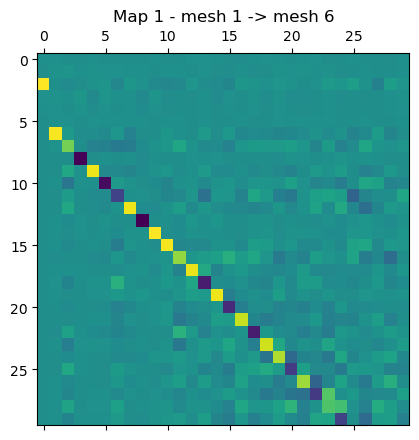

new map shape: (30, 30)


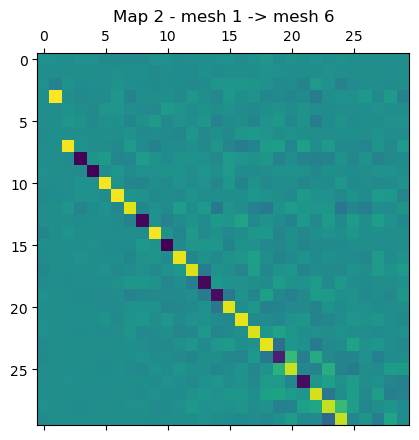

In [ ]:
compound_dict = optimised_dict(mesh_list)

maps_dict = 90
optimised_dict = 90
new map shape: (30, 30)


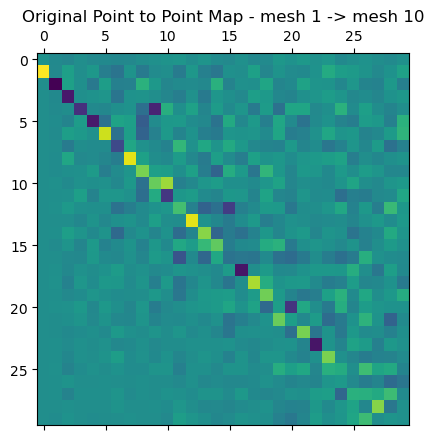

new map shape: (30, 30)


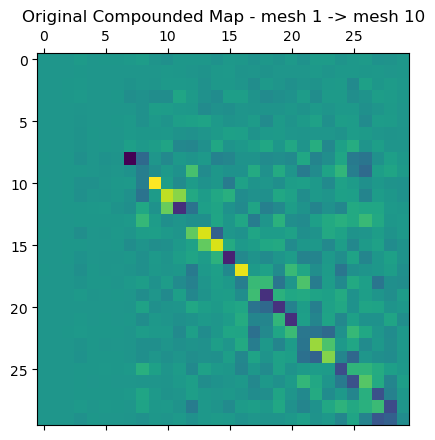

In [56]:
ind1 = 0
ind2 = 9
print(f"maps_dict = {len(maps_dict)}")
print(f"optimised_dict = {len(compound_dict)}")
double_fm_display(ind1, ind2, maps_dict, compound_dict)

# Step 2. Creating the FMN model and CZ Refinement

[talk about the weight decay method briefly]

In [33]:
from FMN_Edited import FMN_Edited

## add parameters for interval size, alpha and beta for the weight boost

# Build the network
fmn_model_new = FMN_Edited(mesh_list, compound_dict.copy())

Setting 90 edges on 10 nodes.


In [34]:
fmn_model_new.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='new',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True, alpha=0.3, beta=2.0, interval=INTERVAL)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay
With Sequential Decay


In [35]:
# To Save or Load Model
import pickle as p

#save
with open("../../true_compound_maps_10_w_decay.pkl", "wb") as f:
    p.dump(fmn_model_new.maps, f)

# # load
# with open("../../fmn_compound_maps_10_w_decay.pkl", "rb") as f:
#     fmn_model_new.maps = p.load(f)
#     #new_maps_dict = p.load(f)

# Step 3. Evaluation

Setting up the original Consistent ZoomOut method as the ground truth for benchmarking.

In [22]:
from pyFM.FMN import FMN
fmn_model_old = FMN(mesh_list, compound_dict.copy())

Setting 90 edges on 10 nodes.


In [23]:
fmn_model_old.zoomout_refine(nit=25, step=2, subsample=3000, isometric=True, weight_type='icsm',
                    M_init=None, cclb_ratio=.9, n_jobs=1, equals_id=False,
                    verbose=True)

Computing a 3000-sized subsample for each mesh


  0%|          | 0/24 [00:00<?, ?it/s]

In [24]:
# save
with open("../../true_compounded_maps_10.pkl", "wb") as f:
    p.dump(fmn_model_old.maps, f)

# # load
# with open("../../fmn_compounded_maps_10.pkl", "rb") as f:
#     fmn_model_old.maps = p.load(f)
#     #old_maps_dict = p.load(f)

## Displaying Maps for Visualisation

new map shape: (78, 78)


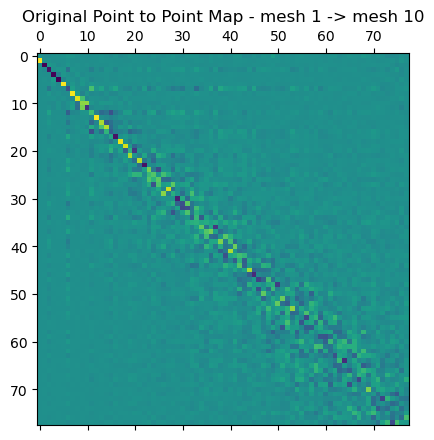

new map shape: (78, 78)


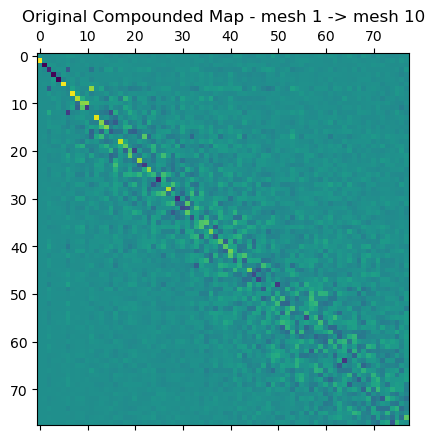

In [59]:
ind_1 = 0
ind_2 = 9
new_maps_dict = fmn_model_new.maps
old_maps_dict = fmn_model_old.maps

double_fm_display(ind_1, ind_2, new_maps_dict, old_maps_dict, meshes=mesh_list)


## Evaluation Against the Ground Truth
Uses the euclidean distances between the points matched on the same pointcloud by both CZ Refinement methods to find the error in the maps.

In [39]:
ind_1 = 0
ind_2 = 8

mesh1, mesh2 = mesh_list[ind_1], mesh_list[ind_2]
gt_target1, gt_target2 = gt_list[ind_1], gt_list[ind_2]

new_maps_dict = fmn_model_new.maps
new_fm_12 = new_maps_dict[(ind_1, ind_2)]

old_maps_dict = fmn_model_old.maps
old_fm_12 = old_maps_dict[(ind_1, ind_2)]

new_p2p_21 = spectral.convert.mesh_FM_to_p2p(new_fm_12, mesh1, mesh2)
old_p2p_21 = spectral.convert.mesh_FM_to_p2p(old_fm_12, mesh1, mesh2)
                                
# plot errors? metrics like mean, standard deviation? whats the best way to do it?



Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

Just Trying to Keep track of each iteration:   0%|          | 0/10 [00:00<?, ?it/s]

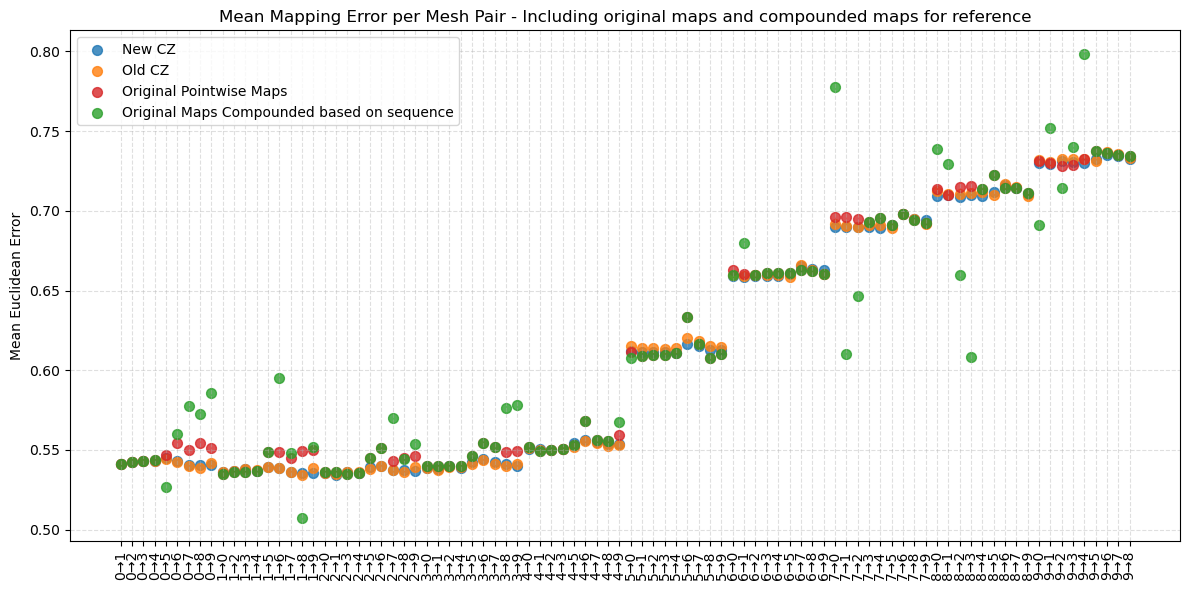

In [41]:
def pointwise_euclidean_error(p2p_map, gt_target_pcd, source_mesh):
    gt_points = np.asarray(gt_target_pcd.points)
    mapped_points = gt_points[p2p_map]

    src_points = np.asarray(source_mesh.vertices)    
    return np.linalg.norm(src_points - mapped_points, axis=1)

errors_new = {}
errors_old = {}

original_errors_maps = {}
original_errors_compounded = {}

for i in range(len(mesh_list)):
    for j in tqdm(range(len(mesh_list)), "Just Trying to Keep track of each iteration"):
        if i == j:
            continue

        mesh1, mesh2 = mesh_list[i], mesh_list[j]
        gt_target = gt_list[i]

        # Adding the original pointwise maps as well
        original_map = maps_dict[(i, j)]
        original_compound_map = compound_dict[(i, j)] # Note: These are the maps we ran refinement on

        original_map_p2p = spectral.convert.mesh_FM_to_p2p(original_map, mesh1, mesh2)
        original_compound_map_p2p = spectral.convert.mesh_FM_to_p2p(original_compound_map, mesh1, mesh2)

        err_o_map = pointwise_euclidean_error(original_map_p2p, gt_target, mesh2)
        err_o_compound_map = pointwise_euclidean_error(original_compound_map_p2p, gt_target, mesh2)

        original_errors_maps[(i, j)] = err_o_map
        original_errors_compounded[(i, j)] = err_o_compound_map


        # Get functional maps
        new_fm = fmn_model_new.maps[(i, j)]
        old_fm = fmn_model_old.maps[(i, j)]

        # Convert to point-to-point maps
        new_p2p = spectral.convert.mesh_FM_to_p2p(new_fm, mesh1, mesh2)
        old_p2p = spectral.convert.mesh_FM_to_p2p(old_fm, mesh1, mesh2)
        
        # Compute errors
        err_new = pointwise_euclidean_error(new_p2p, gt_target, mesh2)
        err_old = pointwise_euclidean_error(old_p2p, gt_target, mesh2)

        errors_new[(i, j)] = err_new
        errors_old[(i, j)] = err_old

# Compute mean errors
mean_errors_new = []
mean_errors_old = []

mean_original_maps = []
mean_compounded_maps = []

map_labels = []

for (i, j) in errors_new:
    mean_errors_new.append(np.mean(errors_new[(i, j)]))
    mean_errors_old.append(np.mean(errors_old[(i, j)]))
    
    mean_original_maps.append(np.mean(original_errors_maps[(i, j)]))
    mean_compounded_maps.append(np.mean(original_errors_compounded[(i, j)]))
    
    map_labels.append(f"{i}→{j}")

# Plot
plt.figure(figsize=(12,6))
plt.scatter(range(len(mean_errors_new)), mean_errors_new, c='tab:blue', label='New CZ', s=50, alpha=0.8)
plt.scatter(range(len(mean_errors_old)), mean_errors_old, c='tab:orange', label='Old CZ', s=50, alpha=0.8)

plt.scatter(range(len(mean_original_maps)), mean_original_maps, c='tab:red', label='Original Pointwise Maps', s=50, alpha=0.8)
plt.scatter(range(len(mean_compounded_maps)), mean_compounded_maps, c='tab:green', label='Original Maps Compounded based on sequence', s=50, alpha=0.8)

plt.xticks(range(len(mean_errors_new)), map_labels, rotation=90)
plt.ylabel("Mean Euclidean Error")
plt.title("Mean Mapping Error per Mesh Pair - Including original maps and compounded maps for reference")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [42]:
with open("current_errors_new.json", "wb") as f:
    p.dump(errors_new, f)

with open("currrent_errors_old.json", "wb") as f:
    p.dump(errors_old, f)

with open("original_p2p_errors.json", "wb") as f:
    p.dump(original_errors_maps, f)

with open("original_compound_p2p_errors.json", "wb") as f:
    p.dump(original_errors_compounded, f)

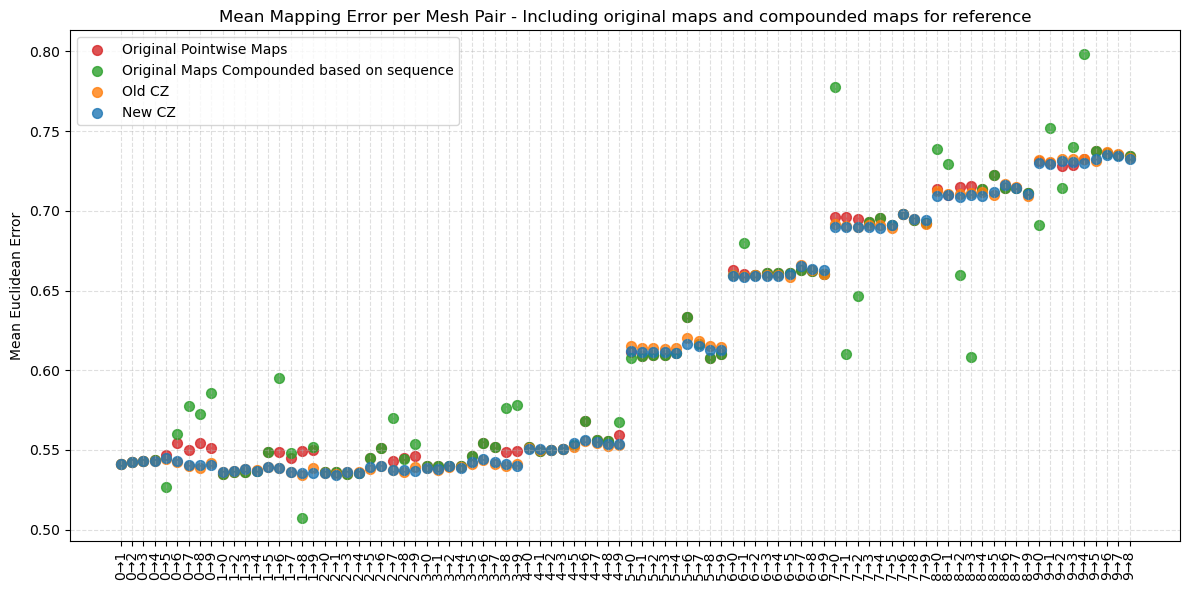

In [44]:
# Plot
plt.figure(figsize=(12,6))

plt.scatter(range(len(mean_original_maps)), mean_original_maps, c='tab:red', label='Original Pointwise Maps', s=50, alpha=0.8)
plt.scatter(range(len(mean_compounded_maps)), mean_compounded_maps, c='tab:green', label='Original Maps Compounded based on sequence', s=50, alpha=0.8)

plt.scatter(range(len(mean_errors_old)), mean_errors_old, c='tab:orange', label='Old CZ', s=50, alpha=0.8)
plt.scatter(range(len(mean_errors_new)), mean_errors_new, c='tab:blue', label='New CZ', s=50, alpha=0.8)

plt.xticks(range(len(mean_errors_new)), map_labels, rotation=90)
plt.ylabel("Mean Euclidean Error")
plt.title("Mean Mapping Error per Mesh Pair - Including original maps and compounded maps for reference")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Old test

In [ ]:
def pointwise_euclidean_error(p2p_map, gt_target_pcd):
    gt_points = np.asarray(gt_target_pcd.points)
    mapped_points = gt_points[p2p_map]

    pointwise_error = []
    for i in range(len(mapped_points)):
        pointwise_error.append(np.linalg.norm(mapped_points[i]- gt_points[i]))

    return pointwise_error

errors_new = {}
errors_old = {}  # store errors per map

for i in range(len(mesh_list)):
    for j in range(len(mesh_list)):
        if i == j:
            continue

        mesh1, mesh2 = mesh_list[i], mesh_list[j]
        gt_target = gt_list[j]

        # Get maps
        new_fm = fmn_model_new.maps[(i, j)]
        old_fm = fmn_model_old.maps[(i, j)]

        # Convert to point-to-point
        new_p2p = spectral.convert.mesh_FM_to_p2p(new_fm, mesh1, mesh2)
        old_p2p = spectral.convert.mesh_FM_to_p2p(old_fm, mesh1, mesh2)

        # Compute per-point error
        err_new = pointwise_euclidean_error(new_p2p, gt_target)
        err_old = pointwise_euclidean_error(old_p2p, gt_target)

        errors_new[(i, j)] = err_new
        errors_old[(i, j)] = err_old

KeyboardInterrupt: 

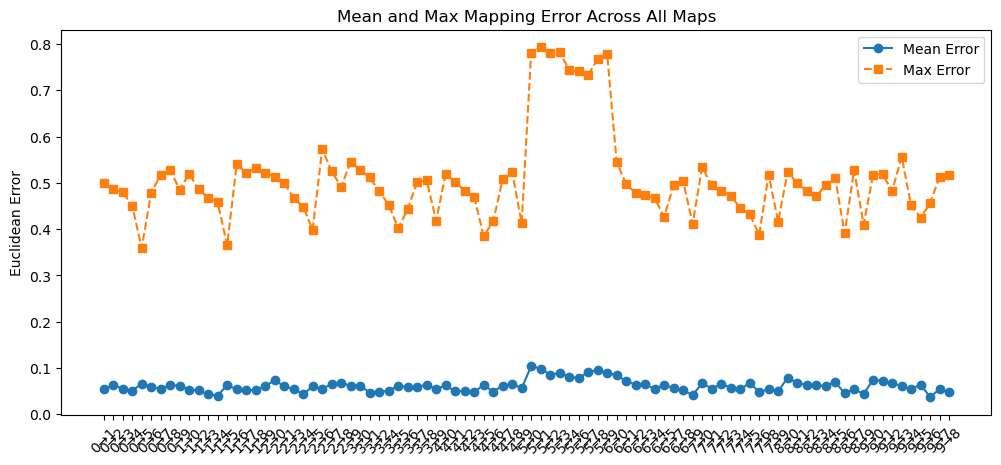

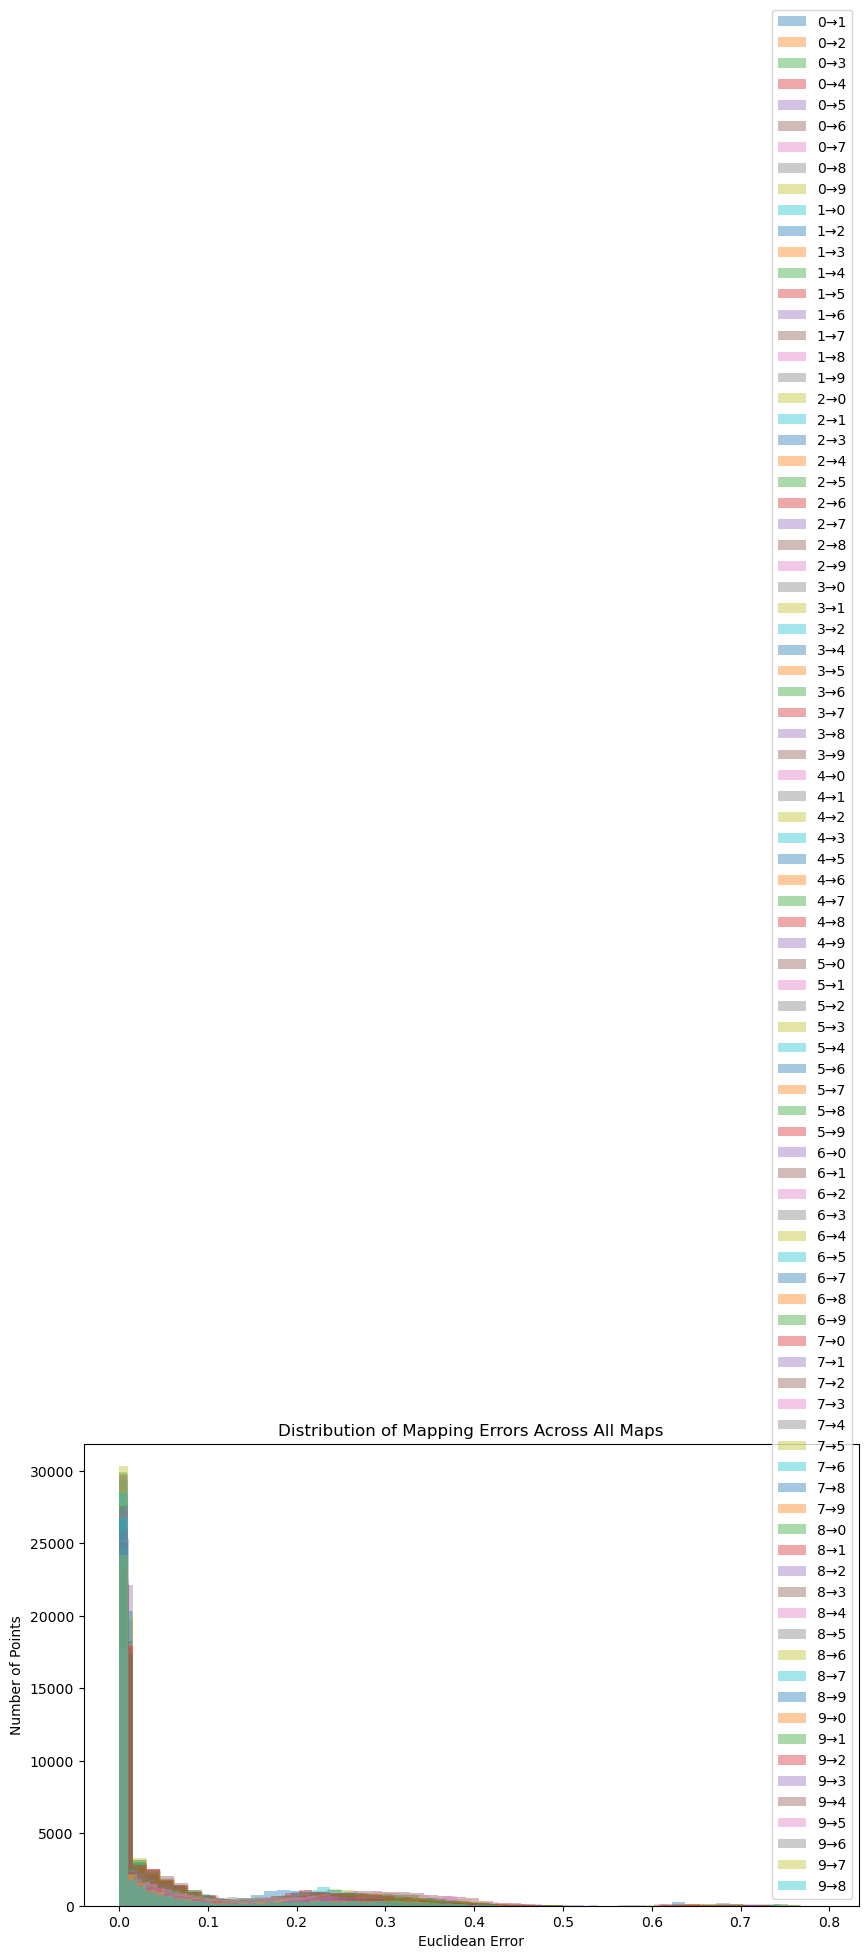

/home/humense/anaconda3/envs/capstone/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


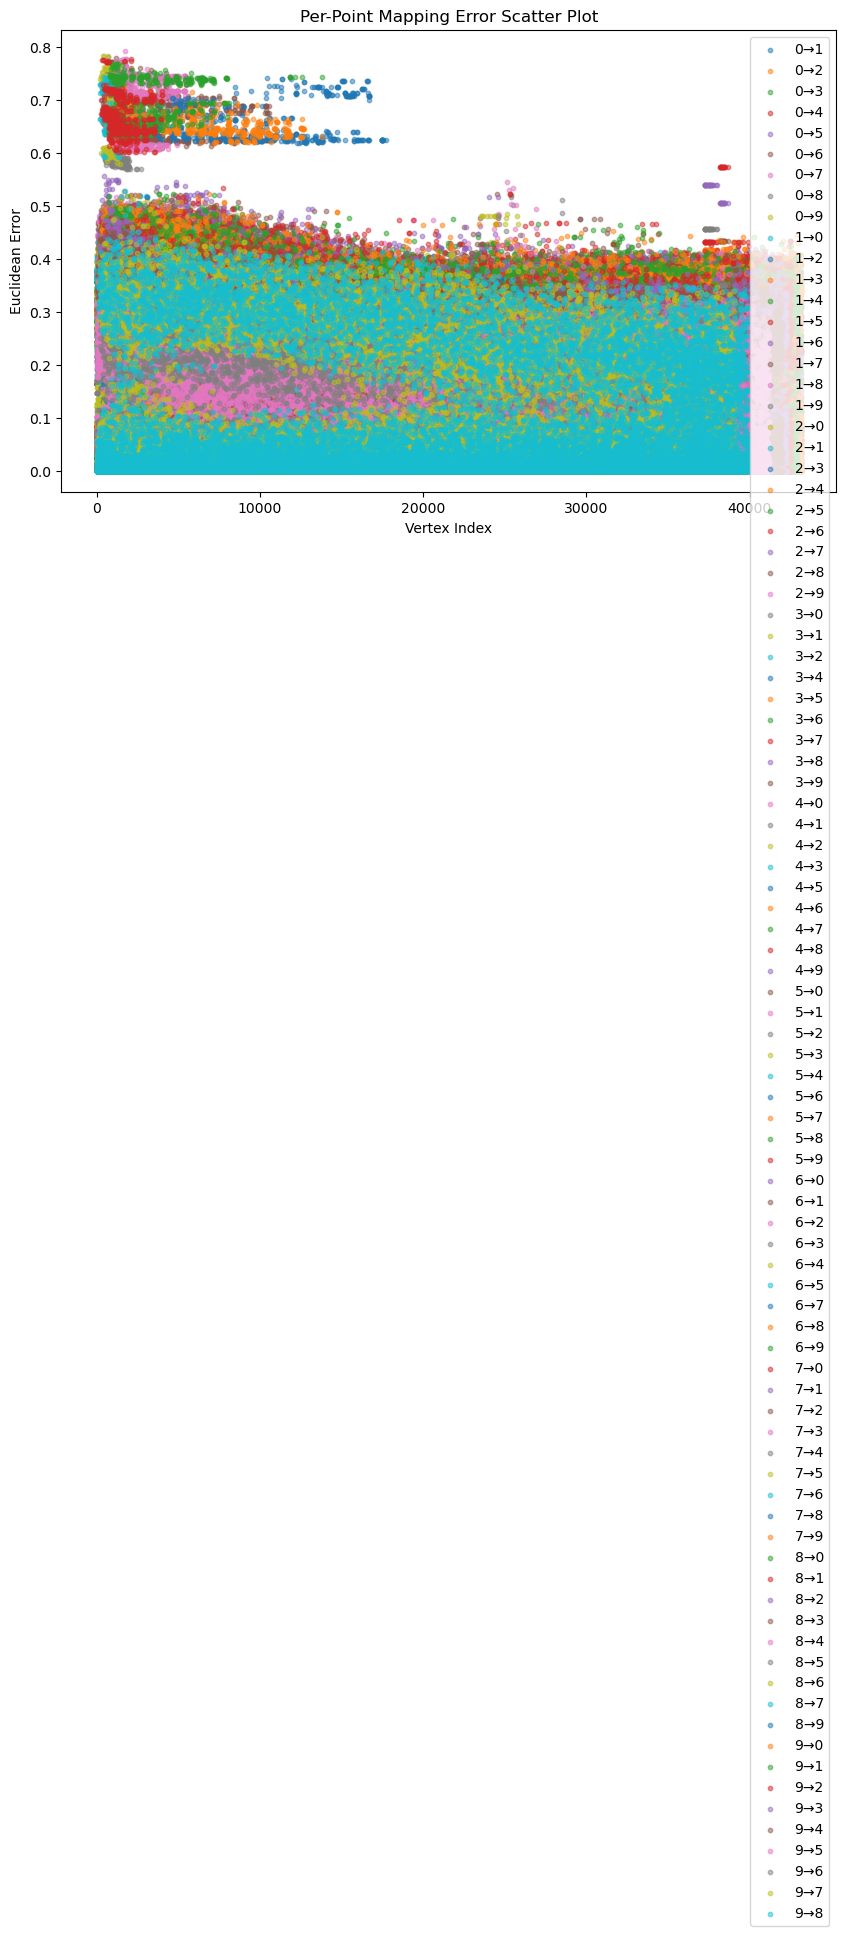

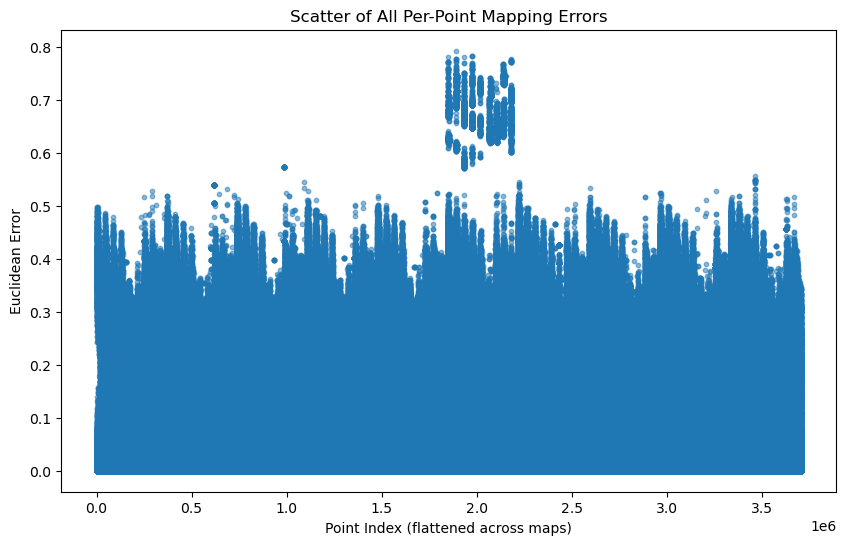

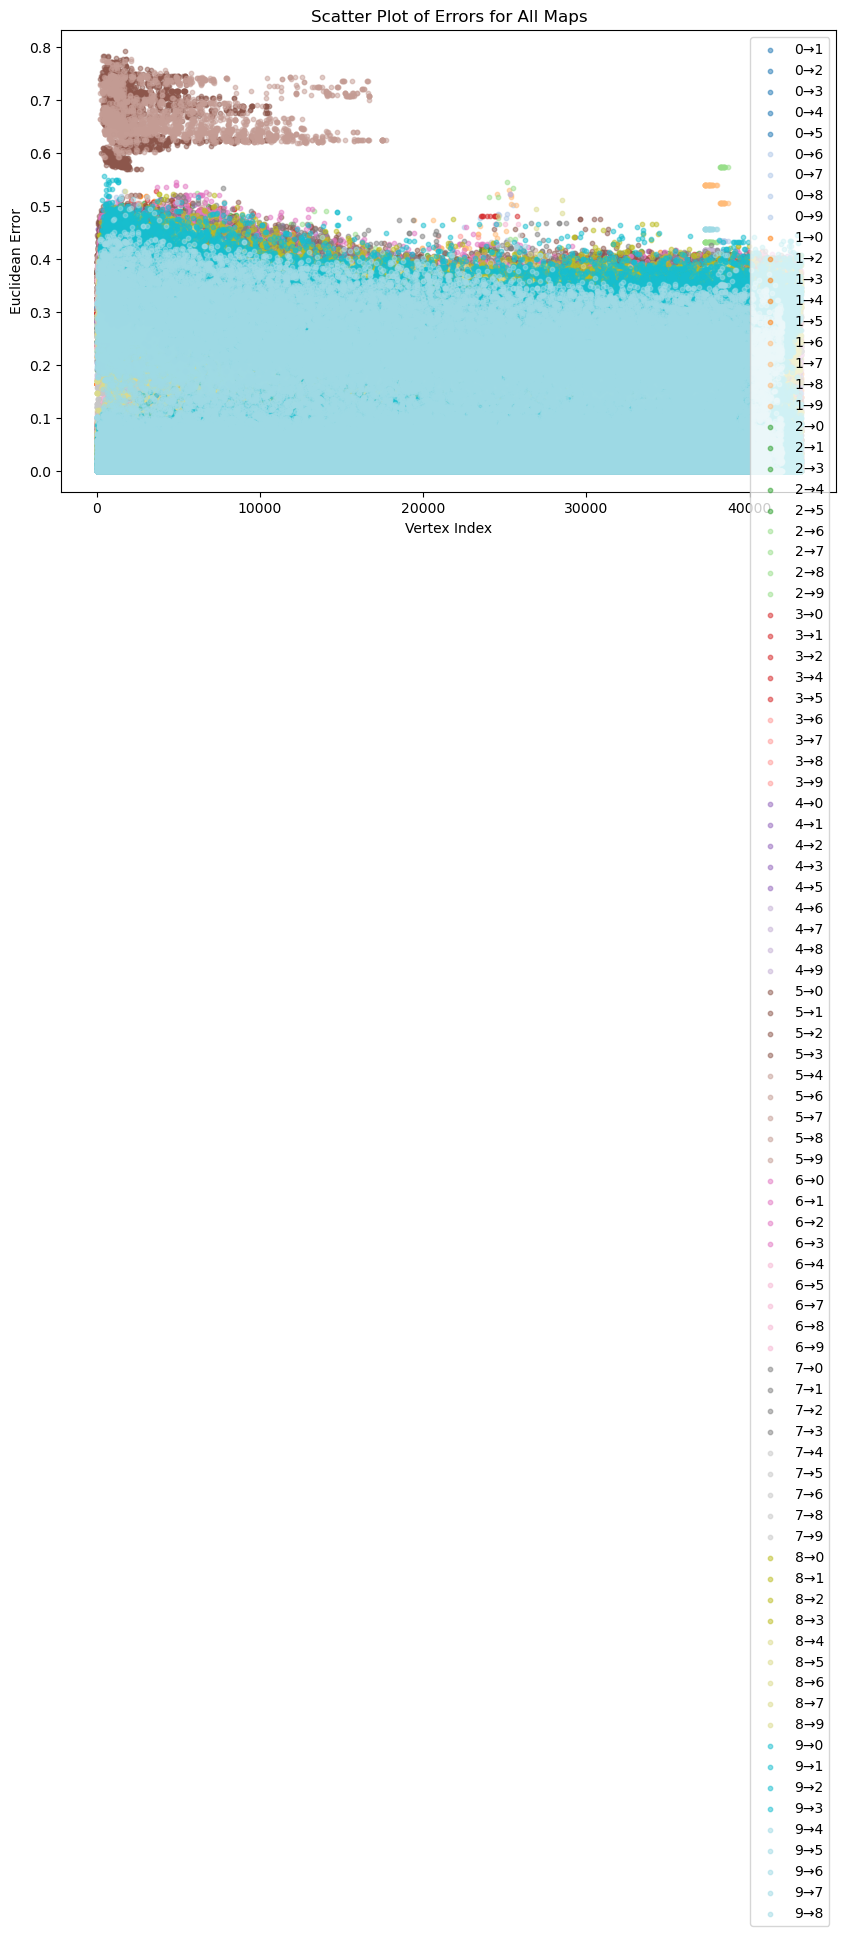

In [ ]:
# with open("current_errors.json", "wb") as f:
#     p.dump(all_errors, f)

map_labels = [f'{k[0]}→{k[1]}' for k in all_errors.keys()]
mean_errors = [np.mean(v) for v in all_errors.values()]
max_errors = [np.max(v) for v in all_errors.values()]

plt.figure(figsize=(12,5))
plt.plot(map_labels, mean_errors, 'o-', label='Mean Error')
plt.plot(map_labels, max_errors, 's--', label='Max Error')
plt.xticks(rotation=45)
plt.ylabel("Euclidean Error")
plt.title("Mean and Max Mapping Error Across All Maps")
plt.legend()
plt.show()


plt.figure(figsize=(10,6))
for key, errs in all_errors.items():
    plt.hist(errs, bins=50, alpha=0.4, label=f'{key[0]}→{key[1]}')

plt.xlabel("Euclidean Error")
plt.ylabel("Number of Points")
plt.title("Distribution of Mapping Errors Across All Maps")
plt.legend()
plt.show()


plt.figure(figsize=(10,6))
for key, errs in all_errors.items():
    vertex_indices = np.arange(len(errs))  # x-axis: vertex index
    plt.scatter(vertex_indices, errs, s=10, alpha=0.5, label=f'{key[0]}→{key[1]}')

plt.xlabel("Vertex Index")
plt.ylabel("Euclidean Error")
plt.title("Per-Point Mapping Error Scatter Plot")
plt.legend()
plt.show()


plt.figure(figsize=(10,6))
all_errs = np.concatenate(list(all_errors.values()))
plt.scatter(range(len(all_errs)), all_errs, s=10, alpha=0.5)
plt.xlabel("Point Index (flattened across maps)")
plt.ylabel("Euclidean Error")
plt.title("Scatter of All Per-Point Mapping Errors")
plt.show()


plt.figure(figsize=(10,6))
colors = plt.cm.tab20(np.linspace(0,1,len(all_errors)))
for (key, errs), color in zip(all_errors.items(), colors):
    plt.scatter(np.arange(len(errs)), errs, s=10, alpha=0.5, color=color, label=f'{key[0]}→{key[1]}')

plt.xlabel("Vertex Index")
plt.ylabel("Euclidean Error")
plt.title("Scatter Plot of Errors for All Maps")
plt.legend()
plt.show()

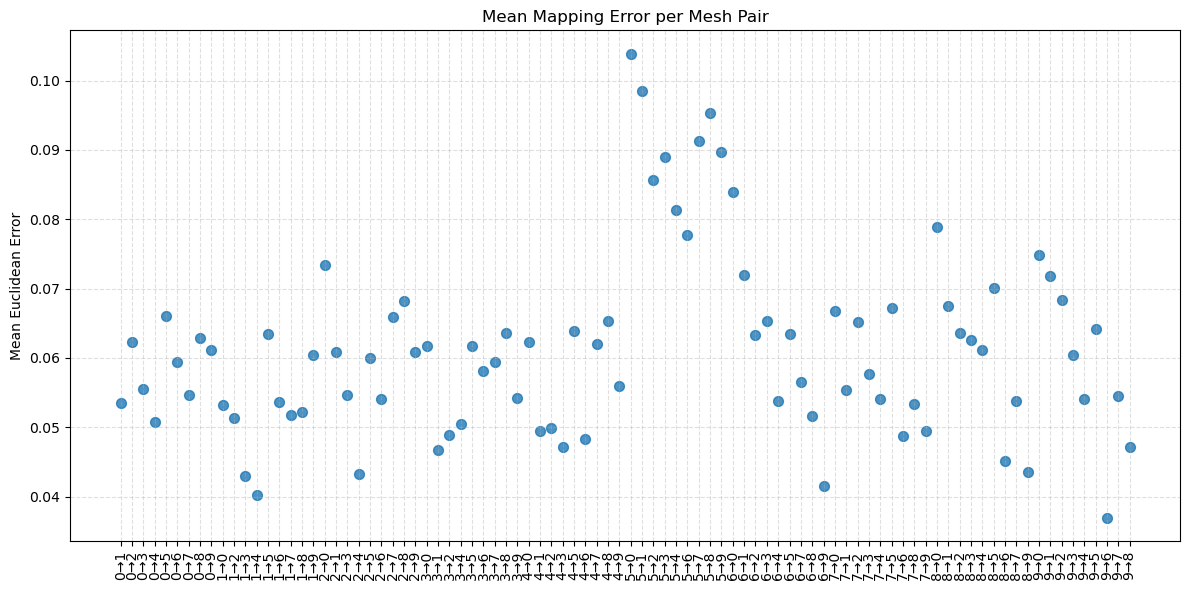

In [ ]:
# Assuming you already have all_errors = {(i, j): np.array([...]), ...}
mean_errors_new = []
map_labels = []

for (i, j), errs in errors_new.items():
    mean_errors_new.append(np.mean(errs))
    map_labels.append(f"{i}→{j}")

mean_errors_new = np.array(mean_errors_new)

mean_errors_old = []

for errs in errors_old.items():
    mean_errors_old.append(np.mean(errs))

mean_errors_new = np.array(mean_errors_new)
mean_errors_old = np.array(mean_errors_old)

# --- Scatter plot version ---
plt.figure(figsize=(12,6))
plt.scatter(range(len(mean_errors_new)), mean_errors_new, c='tab:blue', s=50, alpha=0.8)
plt.scatter(range(len(mean_errors_old)), mean_errors_old, c='tab:orange', s=50, alpha=0.8)
plt.xticks(range(len(mean_errors)), map_labels, rotation=90)
plt.ylabel("Mean Euclidean Error")
plt.title("Mean Mapping Error per Mesh Pair")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

